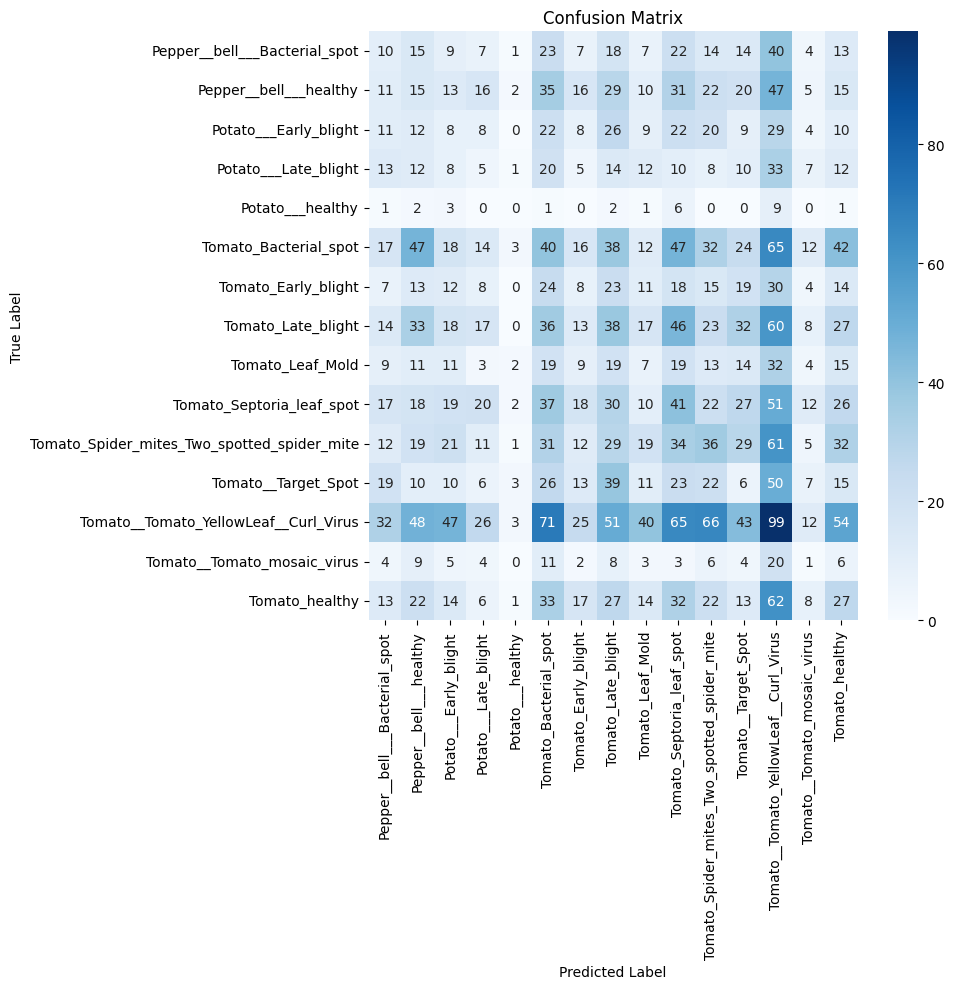

In [47]:
### PLANT DISEASE DETECTION USING CNN
## Created By Bareera Mushthak


## DATASET DOWNLOAD
from google.colab import files
uploaded=files.upload()
#create kaggle folder and set permission
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
#download dataset
!kaggle datasets download -d emmarex/plantdisease
#unzip the downloaded dataset
import zipfile
zip_ref=zipfile.ZipFile('plantdisease.zip','r')
zip_ref.extractall('/content/Plant_disease')
zip_ref.close()

#Load dataset using tensor flow
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

## LOAD DATASET FROM DIRECTORY
dataset_dir='/content/Plant_disease/PlantVillage'
train_dataset=image_dataset_from_directory(dataset_dir,
                                            labels='inferred',
                                            label_mode='categorical',
                                            image_size=(180,180),
                                            batch_size=32,
                                            shuffle=True )

class_names=train_dataset.class_names # automatically detected from folders
## PREPROCESSING
normalization_layer= tf.keras.layers.Rescaling(1./255) # create normalization layer
train_dataset=train_dataset.map(lambda x, y : (normalization_layer(x),y)) # applying normalization to pixel values keeping labels same
#To display some sample images

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
for images,labels in train_dataset.take(1):
  for i in range(10):
    ax=plt.subplot(2,5,i+1)
    plt.imshow(images[i].numpy())
    label_idx = tf.argmax(labels[i].numpy())
    plt.title(class_names[label_idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

## CNN MODEL BUILDING
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
model = Sequential([
                    Input(shape=(180,180,3)),
                    Conv2D(32, (3,3) , activation='relu'),
                    MaxPooling2D(pool_size=(2,2)),

                    Conv2D(64, (3,3) , activation='relu'),
                    MaxPooling2D(pool_size=(2,2)),

                    Conv2D(128, (3,3) , activation='relu'),
                    MaxPooling2D(pool_size=(2,2)),

                    Flatten(),
                    Dense(128, activation='relu'),
                    Dropout(0.5),
                    Dense(15, activation='softmax') #15 class so 15 neurons
                    ])

## COMPILE THE MODEL
model.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics= ['accuracy']
               )
# To create validation dataset to train the model
train_batches = tf.data.experimental.cardinality(train_dataset)
print("Total Batches:",train_batches.numpy())

val_size= int(0.2 * train_batches.numpy()) # 20% for validation
train_size = train_batches.numpy() - val_size
val_dataset= train_dataset.take(val_size) # to take 20% for validation
train_dataset= train_dataset.skip(val_size)# to keep 80% for training
print("train Batches:",train_size)
print("val Batches:",val_size)
print(tf.data.experimental.cardinality(val_dataset).numpy())# To check no.of batches in val_dataset

####  TRAIN CNN MODEL
history = model.fit(train_dataset,validation_data=val_dataset, epochs=10)

### Save the model
model.save('/content/Plant_disease_model.h5')

## Predict labels for validation dataset


import numpy as np
val_predictions= model.predict(val_dataset)# to predict all validation images together
y_pred=np.argmax(val_predictions,axis=1) # to convert probabilities to class labels
y_true= []

for images,labels in val_dataset:
  true_labels=tf.argmax(labels, axis=1)
  y_true.extend(true_labels.numpy())

y_true = np.array(y_true) # to convert y_true to numpy array

## CONFUSION MATRIX
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# create confusion matrix
cm= confusion_matrix(y_true, y_pred)
# plot confusion matrix
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True ,fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
# To save confusion matrix
plt.savefig('confusion_matrix.png')
plt.show()


## Create classification report
from sklearn.metrics import classification_report
report=classification_report(y_true,y_pred,target_names=class_names)
print(report)

## Display some sample images
plt.figure(figsize=(15,5))

for images,labels in val_dataset.take(1):
  predictions=model.predict(images)
  predicted_labels=tf.argmax(predictions,axis=1)
  true_labels=tf.argmax(labels,axis=1)

  for i in range(10):
    ax=plt.subplot(2,5,i+1)
    plt.imshow(images[i].numpy())
    plt.title(f"Actual:{class_names[true_labels[i]]}\nPredicted:{class_names[predicted_labels[i]]}",fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()



In [ ]:

from google.colab import drive
drive.mount('/content/drive')